In [1]:
import hashlib
import io
import logging
import re
import urllib.request
import zipfile
from pathlib import Path

%pip install --quiet --disable-pip-version-check torch==2.14.1
%pip install --quiet --disable-pip-version-check prophet==1.4.0
%pip install --quiet --disable-pip-version-check numpy==2.5.3
%pip install --quiet --disable-pip-version-check pandas==3.0.6
%pip install --quiet --disable-pip-version-check scikit-learn==1.9.1
%pip install --quiet --disable-pip-version-check matplotlib==3.11.2
%pip install --quiet --disable-pip-version-check plotly==7.1.0
%pip install --quiet --disable-pip-version-check ipywidgets==8.1.9

logging.basicConfig(level=logging.WARNING)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from prophet import Prophet
from sklearn.metrics import accuracy_score, balanced_accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from IPython.display import display

logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
torch.set_num_threads(2)
torch.use_deterministic_algorithms(True)
pd.options.display.max_columns = 12
pd.options.display.float_format = "{:.3f}".format
ROOT = Path.cwd()
OUTPUT = ROOT / "results"
OUTPUT.mkdir(exist_ok=True)

In [2]:
FACTORS = ["Value", "Profitability", "Momentum"]
MODELS = ["Historical mean", "Last observed", "LSTM", "Prophet"]
SETTINGS = {
    "as_of_date": "2026-10-04",
    "training_months": 240,
    "test_months": 60,
    "lookback_months": 12,
    "publication_gap_months": 1,
    "lstm_hidden_units": 16,
    "lstm_epochs": 80,
    "learning_rate": 0.005,
    "weight_decay": 0.001,
    "random_seed": 42,
}
HORIZON = SETTINGS["publication_gap_months"] + 1
SOURCE = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
FILES = {
    "Emerging_5_Factors_CSV.zip": ["HML", "RMW"],
    "Emerging_MOM_Factor_CSV.zip": ["WML"],
}
display(pd.Series({
    "Target": "Next month's long-short factor return (%)",
    "Trend": "Up above 0; Down below 0; Flat at 0",
    "Data": "Kenneth French emerging-market monthly factors",
    "LSTM": "12 months of all three factors; three return forecasts",
    "Prophet": "One model per factor; monthly forecasts; no seasonality",
    "Publication gap": "One month assumed; historical release dates are unavailable",
    "Data vintage": "Latest downloaded values; not historical vintages",
    "Evaluation": "Rolling forecasts with fixed settings; no test-set tuning",
}, name="Experiment").to_frame())
display(pd.Series(SETTINGS, name="Setting").to_frame())

,Experiment
Target,Next month's long-short factor return (%)
Trend,Up above 0; Down below 0; Flat at 0
Data,Kenneth French emerging-market monthly factors
LSTM,12 months of all three factors; three return f...
Prophet,One model per factor; monthly forecasts; no se...
Publication gap,One month assumed; historical release dates ar...
Data vintage,Latest downloaded values; not historical vintages
Evaluation,Rolling forecasts with fixed settings; no test...


,Setting
as_of_date,2026-10-04
training_months,240
test_months,60
lookback_months,12
publication_gap_months,1
lstm_hidden_units,16
lstm_epochs,80
learning_rate,0.005
weight_decay,0.001
random_seed,42


In [3]:
def read_monthly(path, columns):
    with zipfile.ZipFile(path) as archive:
        member = next(name for name in archive.namelist() if name.lower().endswith(".csv"))
        lines = archive.read(member).decode("utf-8-sig").splitlines()
    first = next(i for i, line in enumerate(lines) if re.match(r"^\s*\d{6}\s*,", line))
    last = first
    while last < len(lines) and re.match(r"^\s*\d{6}\s*,", lines[last]):
        last += 1
    frame = pd.read_csv(io.StringIO("\n".join(lines[first - 1:last])), index_col=0)
    frame.columns = frame.columns.str.strip()
    frame = frame[columns].apply(pd.to_numeric, errors="raise").replace([-99.99, -999], np.nan)
    frame.index = pd.to_datetime(frame.index.astype(str).str.strip(), format="%Y%m") + pd.offsets.MonthEnd(0)
    if not (frame.index.is_unique and frame.index.is_monotonic_increasing):
        raise ValueError('Monthly dates must be unique and ordered.')
    return frame

In [4]:
tables, sources = [], []
(ROOT / "data").mkdir(exist_ok=True)
for filename, columns in FILES.items():
    path = ROOT / "data" / filename
    if not path.exists():
        with urllib.request.urlopen(SOURCE + filename, timeout=30) as response:
            path.write_bytes(response.read())
    tables.append(read_monthly(path, columns))
    sources.append({"File": filename, "Source": SOURCE + filename, "SHA256": hashlib.sha256(path.read_bytes()).hexdigest()})
data = pd.concat(tables, axis=1).dropna().rename(columns={"HML": "Value", "RMW": "Profitability", "WML": "Momentum"})
data = data.loc[data.index < pd.Timestamp(SETTINGS["as_of_date"]).replace(day=1), FACTORS]
data.index.name = "Month"
if not (data.index.to_period("M").equals(pd.period_range(data.index[0], data.index[-1], freq="M"))):
    raise ValueError('The monthly history contains gaps.')
if not (np.isfinite(data.to_numpy()).all()):
    raise ValueError('The monthly history contains invalid returns.')
if not (len(data) >= SETTINGS["training_months"] + SETTINGS["test_months"] + HORIZON):
    raise ValueError('There is not enough monthly history.')
display(pd.DataFrame(sources))
display(pd.DataFrame({"First month": [data.index[0]], "Last month": [data.index[-1]], "Months": [len(data)]}))
display(data.tail(6))

,File,Source,SHA256
0,Emerging_5_Factors_CSV.zip,https://mba.tuck.dartmouth.edu/pages/faculty/k...,303b5afb42232683f48f80178206a5cb99b1b755e4dc04...
1,Emerging_MOM_Factor_CSV.zip,https://mba.tuck.dartmouth.edu/pages/faculty/k...,5316f98a394947be155ba97f860366a14b214140d37b75...


,First month,Last month,Months
0,1991-07-31,2026-08-31,422


,Value,Profitability,Momentum
Month,,,
2026-03-31,-0.670,-0.590,-5.030
2026-04-30,-4.330,2.730,12.840
2026-05-31,1.770,4.700,9.580
2026-06-30,1.370,2.070,0.360
2026-07-31,6.700,-0.540,-16.840
2026-08-31,-3.270,-2.450,8.020


In [5]:
def make_sequences(values, lookback, horizon):
    ends = range(lookback - 1, len(values) - horizon)
    inputs = np.array([values[end - lookback + 1:end + 1] for end in ends], dtype=np.float32)
    targets = np.array([values[end + horizon] for end in ends], dtype=np.float32)
    return torch.from_numpy(inputs), torch.from_numpy(targets)

In [6]:
class FactorLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(len(FACTORS), SETTINGS["lstm_hidden_units"], batch_first=True)
        self.output = nn.Linear(SETTINGS["lstm_hidden_units"], len(FACTORS))

    def forward(self, values):
        sequence, _ = self.lstm(values)
        return self.output(sequence[:, -1, :])

In [7]:
def predict_lstm(history):
    torch.manual_seed(SETTINGS["random_seed"])
    scaler = StandardScaler().fit(history)
    values = scaler.transform(history).astype(np.float32)
    inputs, targets = make_sequences(values, SETTINGS["lookback_months"], HORIZON)
    model = FactorLSTM()
    optimizer = torch.optim.Adam(model.parameters(), lr=SETTINGS["learning_rate"], weight_decay=SETTINGS["weight_decay"])
    loss_function = nn.MSELoss()
    model.train()
    for _ in range(SETTINGS["lstm_epochs"]):
        optimizer.zero_grad()
        loss = loss_function(model(inputs), targets)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
    model.eval()
    with torch.no_grad():
        window = torch.from_numpy(values[-SETTINGS["lookback_months"]:]).unsqueeze(0)
        forecast = model(window).numpy()
    return scaler.inverse_transform(forecast)[0]

In [8]:
def predict_prophet(history, target_month):
    forecasts = []
    for factor in FACTORS:
        training = pd.DataFrame({"ds": history.index, "y": history[factor].to_numpy()})
        model = Prophet(
            yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False,
            n_changepoints=10, changepoint_prior_scale=0.05, uncertainty_samples=0,
        )
        model.fit(training, seed=SETTINGS["random_seed"])
        forecast = model.predict(pd.DataFrame({"ds": [target_month]}))
        forecasts.append(float(forecast["yhat"].iloc[0]))
    return np.array(forecasts)

In [9]:
def training_history(frame, target_month):
    cutoff = target_month - pd.offsets.MonthEnd(HORIZON)
    history = frame.loc[frame.index <= cutoff].tail(SETTINGS["training_months"])
    if not (len(history) == SETTINGS["training_months"]):
        raise ValueError('There is not enough monthly history.')
    if not (history.index[-1] == cutoff):
        raise ValueError('The required month is missing from the history.')
    return history


def forecast_month(frame, target_month):
    history = training_history(frame, target_month)
    predictions = {
        "Historical mean": history.mean().to_numpy(),
        "Last observed": history.iloc[-1].to_numpy(),
        "LSTM": predict_lstm(history),
        "Prophet": predict_prophet(history, target_month),
    }
    rows = []
    for model, values in predictions.items():
        for factor, predicted in zip(FACTORS, values):
            rows.append({
                "Data through": history.index[-1],
                "Assumed decision date": target_month - pd.offsets.MonthEnd(1),
                "Target month": target_month,
                "Factor": factor,
                "Model": model,
                "Predicted return %": float(predicted),
            })
    return pd.DataFrame(rows)

In [10]:
forecasts = []
test_dates = data.index[-SETTINGS["test_months"]:]
for count, target_month in enumerate(test_dates, 1):
    forecast = forecast_month(data, target_month)
    forecast["Actual return %"] = forecast["Factor"].map(data.loc[target_month])
    forecasts.append(forecast)
    if count % 12 == 0:
        print(f"Completed {count} / {len(test_dates)} months")
predictions = pd.concat(forecasts, ignore_index=True)
predictions["Predicted trend"] = np.select(
    [predictions["Predicted return %"] > 0, predictions["Predicted return %"] < 0], ["Up", "Down"], default="Flat"
)
predictions["Actual trend"] = np.select(
    [predictions["Actual return %"] > 0, predictions["Actual return %"] < 0], ["Up", "Down"], default="Flat"
)
print("Test period:", test_dates[0].strftime("%b %Y"), "to", test_dates[-1].strftime("%b %Y"))

Completed 12 / 60 months


Completed 24 / 60 months


Completed 36 / 60 months


Completed 48 / 60 months


Completed 60 / 60 months
Test period: Sep 2021 to Aug 2026


In [11]:
scores = []
for (factor, model), group in predictions.groupby(["Factor", "Model"], sort=False):
    actual, predicted = group["Actual return %"], group["Predicted return %"]
    scores.append({
        "Factor": factor, "Model": model, "Months": len(group),
        "Direction accuracy %": accuracy_score(np.sign(actual), np.sign(predicted)) * 100,
        "Balanced accuracy %": balanced_accuracy_score(np.sign(actual), np.sign(predicted)) * 100,
        "MAE (percentage points)": mean_absolute_error(actual, predicted),
        "RMSE (percentage points)": np.sqrt(mean_squared_error(actual, predicted)),
        "Predicted up %": (predicted > 0).mean() * 100,
        "Actual up %": (actual > 0).mean() * 100,
    })
metrics = pd.DataFrame(scores).set_index(["Factor", "Model"]).reindex(pd.MultiIndex.from_product([FACTORS, MODELS], names=["Factor", "Model"]))
display(metrics.round(2))

Months  Direction accuracy %  \
Factor        Model                                           
Value         Historical mean      60                61.670   
              Last observed        60                51.670   
              LSTM                 60                51.670   
              Prophet              60                56.670   
Profitability Historical mean      60                56.670   
              Last observed        60                53.330   
              LSTM                 60                53.330   
              Prophet              60                56.670   
Momentum      Historical mean      60                68.330   
              Last observed        60                58.330   
              LSTM                 60                51.670   
              Prophet              60                68.330   

                               Balanced accuracy %  MAE (percentage points)  \
Factor        Model                                                           
Value         Historical mean               50.000                    1.900   
              Last observed                 48.470                    2.760   
              LSTM                          42.710                    2.090   
              Prophet                       47.590                    2.000   
Profitability Historical mean               33.330                    1.120   
              Last observed                 35.250                    1.480   
              LSTM                          36.310                    1.250   
              Prophet                       33.330                    1.130   
Momentum      Historical mean               50.000                    2.640   
              Last observed                 51.160                    3.810   
              LSTM                          44.870                    3.350   
              Prophet                       50.000                    2.650   

                               RMSE (percentage points)  Predicted up %  \
Factor        Model                                                       
Value         Historical mean                     2.370         100.000   
              Last observed                       3.300          63.330   
              LSTM                                2.590          86.670   
              Prophet                             2.500          88.330   
Profitability Historical mean                     1.460         100.000   
              Last observed                       1.930          60.000   
              LSTM                                1.650          50.000   
              Prophet                             1.460         100.000   
Momentum      Historical mean                     4.130         100.000   
              Last observed                       5.830          70.000   
              LSTM                                4.670          66.670   
              Prophet                             4.150         100.000   

                               Actual up %  
Factor        Model                         
Value         Historical mean       61.670  
              Last observed         61.670  
              LSTM                  61.670  
              Prophet               61.670  
Profitability Historical mean       56.670  
              Last observed         56.670  
              LSTM                  56.670  
              Prophet               56.670  
Momentum      Historical mean       68.330  
              Last observed         68.330  
              LSTM                  68.330  
              Prophet               68.330

In [12]:
recent = predictions.loc[
    predictions["Model"].isin(["LSTM", "Prophet"]) & (predictions["Target month"] >= test_dates[-6]),
    ["Target month", "Factor", "Model", "Predicted return %", "Actual return %", "Predicted trend", "Actual trend"],
].sort_values(["Target month", "Factor", "Model"], ascending=[False, True, True])
display(recent.reset_index(drop=True).round(2))

C:\Users\Arian\AppData\Local\Temp\ipykernel_1596\3612434803.py:5: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(recent.reset_index(drop=True).round(2))


,Target month,Factor,Model,Predicted return %,Actual return %,Predicted trend,Actual trend
0,2026-08-31,Momentum,LSTM,1.800,8.020,Up,Up
1,2026-08-31,Momentum,Prophet,1.430,8.020,Up,Up
2,2026-08-31,Profitability,LSTM,0.890,-2.450,Up,Down
3,2026-08-31,Profitability,Prophet,0.470,-2.450,Up,Down
4,2026-08-31,Value,LSTM,0.660,-3.270,Up,Down
5,2026-08-31,Value,Prophet,0.680,-3.270,Up,Down
6,2026-07-31,Momentum,LSTM,1.580,-16.840,Up,Down
7,2026-07-31,Momentum,Prophet,1.650,-16.840,Up,Down
8,2026-07-31,Profitability,LSTM,0.740,-0.540,Up,Down
9,2026-07-31,Profitability,Prophet,0.440,-0.540,Up,Down


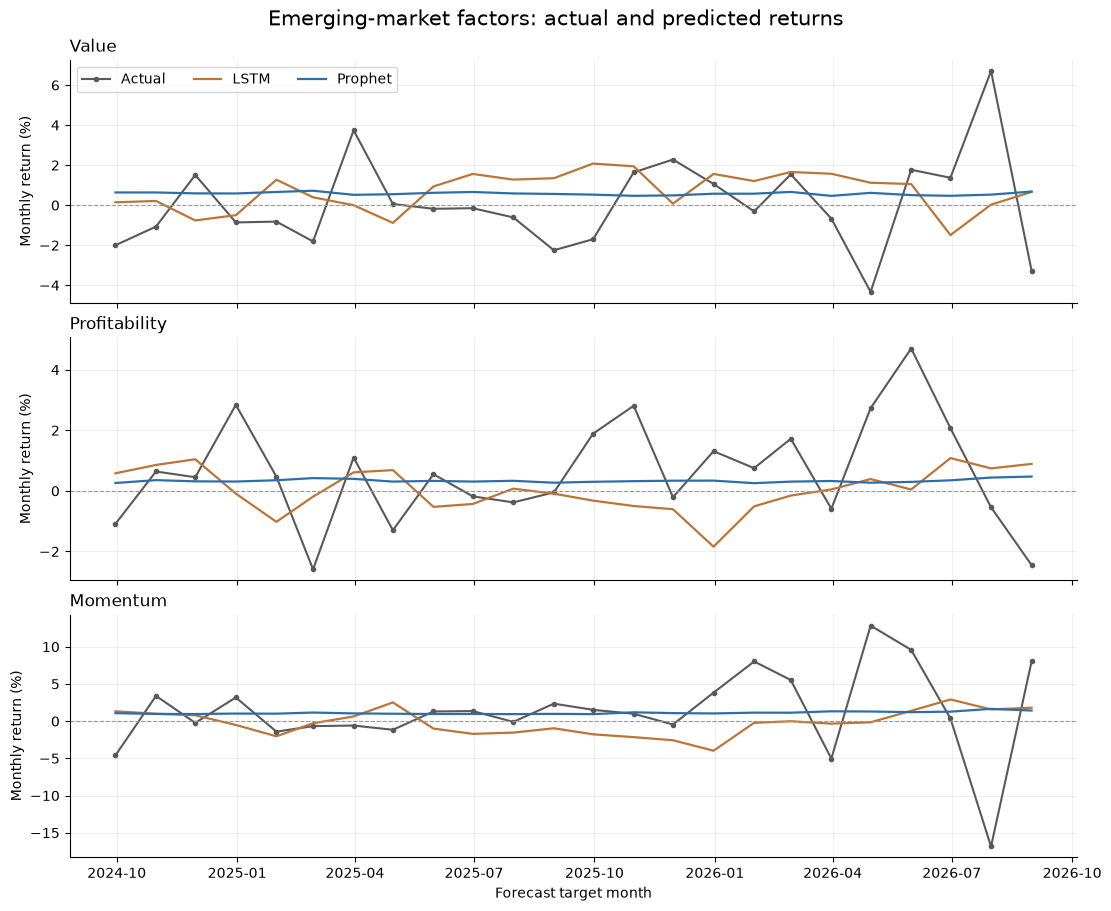

In [13]:
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True, layout="constrained")
for ax, factor in zip(axes, FACTORS):
    selected = predictions.loc[(predictions["Factor"] == factor) & (predictions["Target month"] >= test_dates[-24])]
    actual = selected.drop_duplicates("Target month").set_index("Target month")["Actual return %"]
    ax.plot(actual.index, actual, color="0.35", linewidth=1.5, label="Actual", marker=".")
    for model, color in [("LSTM", "#bb7537"), ("Prophet", "#2d6eaa")]:
        series = selected.loc[selected["Model"] == model].set_index("Target month")["Predicted return %"]
        ax.plot(series.index, series, color=color, linewidth=1.6, label=model)
    ax.axhline(0, color="0.6", linewidth=0.8, linestyle="--")
    ax.set_title(factor, loc="left")
    ax.set_ylabel("Monthly return (%)")
    ax.grid(alpha=0.2)
axes[0].legend(ncol=3, loc="upper left")
axes[-1].set_xlabel("Forecast target month")
fig.suptitle("Emerging-market factors: actual and predicted returns", fontsize=15)
fig.savefig(OUTPUT / "trend_predictions.png", dpi=160)
plt.show()

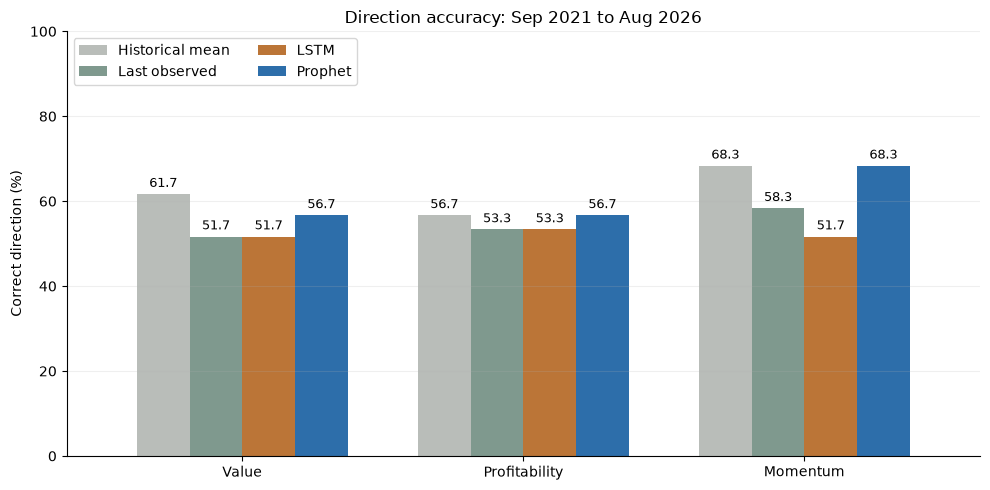

In [14]:
comparison = metrics["Direction accuracy %"].unstack("Model").reindex(index=FACTORS, columns=MODELS)
ax = comparison.plot.bar(figsize=(10, 5), color=["#b9bdb9", "#7f998e", "#bb7537", "#2d6eaa"], width=0.75)
ax.set_ylim(0, 100)
ax.set_ylabel("Correct direction (%)")
ax.set_xlabel("")
ax.set_title(f"Direction accuracy: {test_dates[0]:%b %Y} to {test_dates[-1]:%b %Y}")
ax.tick_params(axis="x", rotation=0)
ax.legend(ncol=2, loc="upper left")
ax.grid(axis="y", alpha=0.2)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT / "model_comparison.png", dpi=160)
plt.show()

In [15]:
next_target = data.index[-1] + pd.offsets.MonthEnd(HORIZON)
latest = forecast_month(data, next_target)
latest = latest.loc[latest["Model"].isin(["LSTM", "Prophet"])].copy()
latest["Predicted trend"] = np.select(
    [latest["Predicted return %"] > 0, latest["Predicted return %"] < 0], ["Up", "Down"], default="Flat"
)
display(latest.reset_index(drop=True).round(2))

C:\Users\Arian\AppData\Local\Temp\ipykernel_1596\3145438893.py:7: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(latest.reset_index(drop=True).round(2))


,Data through,Assumed decision date,Target month,Factor,Model,Predicted return %,Predicted trend
0,2026-08-31,2026-09-30,2026-10-31,Value,LSTM,1.020,Up
1,2026-08-31,2026-09-30,2026-10-31,Profitability,LSTM,0.330,Up
2,2026-08-31,2026-09-30,2026-10-31,Momentum,LSTM,2.570,Up
3,2026-08-31,2026-09-30,2026-10-31,Value,Prophet,0.520,Up
4,2026-08-31,2026-09-30,2026-10-31,Profitability,Prophet,0.390,Up
5,2026-08-31,2026-09-30,2026-10-31,Momentum,Prophet,1.340,Up


In [16]:
data.to_csv(OUTPUT / "monthly_returns.csv")
predictions.to_csv(OUTPUT / "predictions.csv", index=False)
metrics.to_csv(OUTPUT / "metrics.csv")
latest.to_csv(OUTPUT / "latest_forecast.csv", index=False)
display(metrics[["Direction accuracy %", "MAE (percentage points)"]].round(2))

Direction accuracy %  MAE (percentage points)
Factor        Model                                                         
Value         Historical mean                61.670                    1.900
              Last observed                  51.670                    2.760
              LSTM                           51.670                    2.090
              Prophet                        56.670                    2.000
Profitability Historical mean                56.670                    1.120
              Last observed                  53.330                    1.480
              LSTM                           53.330                    1.250
              Prophet                        56.670                    1.130
Momentum      Historical mean                68.330                    2.640
              Last observed                  58.330                    3.810
              LSTM                           51.670                    3.350
              Prophet                        68.330                    2.650

Across Value, Profitability and Momentum, average direction accuracy was 52.2% for LSTM and 60.6% for Prophet. The historical-mean baseline averaged 62.2% over the same 60 months per factor, from September 2021 to August 2026. Looking at each factor separately matters because an average can hide a weak result in one series. We allowed for a publication delay and trained on earlier observations, but these results use today's historical data. They help us compare forecast methods; they do not yet tell us which portfolio would perform best after costs.